In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
original = pd.read_csv(
    "/content/gdrive/My Drive/4_2 project/Sleep_health_and_lifestyle_dataset.csv"
)

smotenc = pd.read_csv(
    "/content/gdrive/My Drive/4_2 project/SMOTENC_1500_Synthetic_Dataset.csv"
)

ctgan = pd.read_csv(
    "/content/gdrive/My Drive/4_2 project/CTGAN_1500_Synthetic_Dataset.csv"
)

In [5]:
original_ml = original.drop(columns=['Person ID']).copy()
smotenc_ml = smotenc.drop(columns=['Person ID']).copy()
ctgan_ml = ctgan.drop(columns=['Person ID']).copy()

In [6]:
X_original = original_ml.drop(columns=['Sleep Disorder'])
y_original = original_ml['Sleep Disorder']

X_smotenc = smotenc_ml.drop(columns=['Sleep Disorder'])
y_smotenc = smotenc_ml['Sleep Disorder']

X_ctgan = ctgan_ml.drop(columns=['Sleep Disorder'])
y_ctgan = ctgan_ml['Sleep Disorder']

In [7]:
print("Original:", X_original.shape, y_original.shape)
print("SMOTENC:", X_smotenc.shape, y_smotenc.shape)
print("CTGAN:", X_ctgan.shape, y_ctgan.shape)

print("\nFeatures:")
print(X_original.columns.tolist())

Original: (559, 11) (559,)
SMOTENC: (1500, 11) (1500,)
CTGAN: (1500, 11) (1500,)

Features:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps']


In [8]:
def split_blood_pressure(df):
    df = df.copy()

    df[['Systolic Pressure', 'Diastolic Pressure']] = (
        df['Blood Pressure']
        .str.split('/', expand=True)
        .astype(int)
    )

    df.drop(columns=['Blood Pressure'], inplace=True)

    return df

In [9]:
X_original = split_blood_pressure(X_original)
X_smotenc = split_blood_pressure(X_smotenc)
X_ctgan = split_blood_pressure(X_ctgan)

In [10]:
print("Original columns:")
print(X_original.columns.tolist())

print("\nSMOTENC columns:")
print(X_smotenc.columns.tolist())

print("\nCTGAN columns:")
print(X_ctgan.columns.tolist())

Original columns:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic Pressure', 'Diastolic Pressure']

SMOTENC columns:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic Pressure', 'Diastolic Pressure']

CTGAN columns:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic Pressure', 'Diastolic Pressure']


In [11]:
categorical_features = [
    'Gender',
    'Occupation',
    'BMI Category'
]

numerical_features = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Systolic Pressure',
    'Diastolic Pressure'
]

In [12]:
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Gender', 'Occupation', 'BMI Category']
Numerical features: ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic Pressure', 'Diastolic Pressure']


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

In [17]:
y_original = y_original.fillna("Healthy")

In [18]:
def train_and_evaluate(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight='balanced'
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return {
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(
            y_test, y_pred, average='weighted', zero_division=0
        ),
        'recall': recall_score(
            y_test, y_pred, average='weighted', zero_division=0
        ),
        'f1': f1_score(
            y_test, y_pred, average='weighted', zero_division=0
        )
    }

In [20]:
results_original = train_and_evaluate(
    X_original,
    y_original
)

results_smotenc = train_and_evaluate(
    X_smotenc,
    y_smotenc
)

results_ctgan = train_and_evaluate(
    X_ctgan,
    y_ctgan
)

In [21]:
comparison = pd.DataFrame({
    'Dataset': [
        'Original',
        'SMOTENC',
        'Conditional CTGAN'
    ],
    'Accuracy': [
        results_original['accuracy'],
        results_smotenc['accuracy'],
        results_ctgan['accuracy']
    ],
    'Precision': [
        results_original['precision'],
        results_smotenc['precision'],
        results_ctgan['precision']
    ],
    'Recall': [
        results_original['recall'],
        results_smotenc['recall'],
        results_ctgan['recall']
    ],
    'F1-Score': [
        results_original['f1'],
        results_smotenc['f1'],
        results_ctgan['f1']
    ]
})

comparison

,Dataset,Accuracy,Precision,Recall,F1-Score
0,Original,0.857143,0.875425,0.857143,0.856616
1,SMOTENC,0.960000,0.960369,0.960000,0.959793
2,Conditional CTGAN,0.730000,0.673875,0.730000,0.687417


In [23]:
comparison_final = comparison.round(4)

comparison_final.to_csv(
    "model_comparison.csv",
    index=False
)

print("model_comparison.csv created successfully.")

model_comparison.csv created successfully.


In [25]:
pd.read_csv("model_comparison.csv")

,Dataset,Accuracy,Precision,Recall,F1-Score
0,Original,0.8571,0.8754,0.8571,0.8566
1,SMOTENC,0.9600,0.9604,0.9600,0.9598
2,Conditional CTGAN,0.7300,0.6739,0.7300,0.6874


In [26]:
from google.colab import files

files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

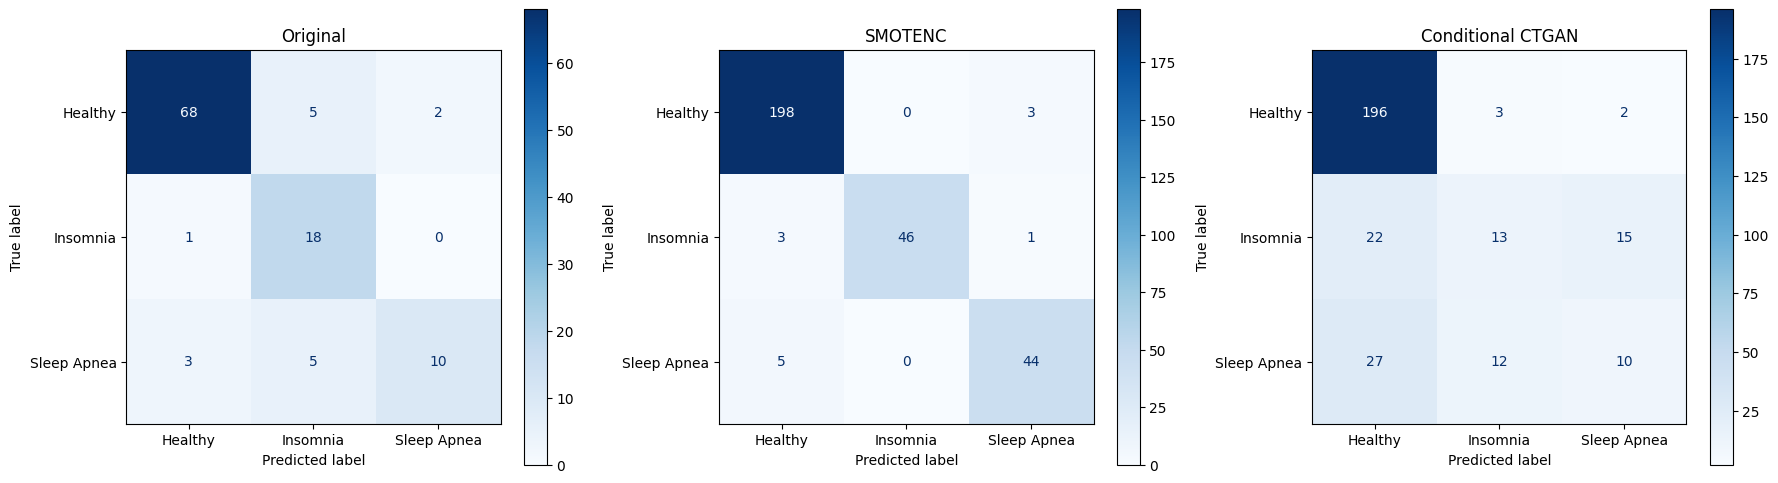

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ("Original", results_original),
    ("SMOTENC", results_smotenc),
    ("Conditional CTGAN", results_ctgan)
]

for ax, (name, result) in zip(axes, datasets):
    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(name)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
from google.colab import files

files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

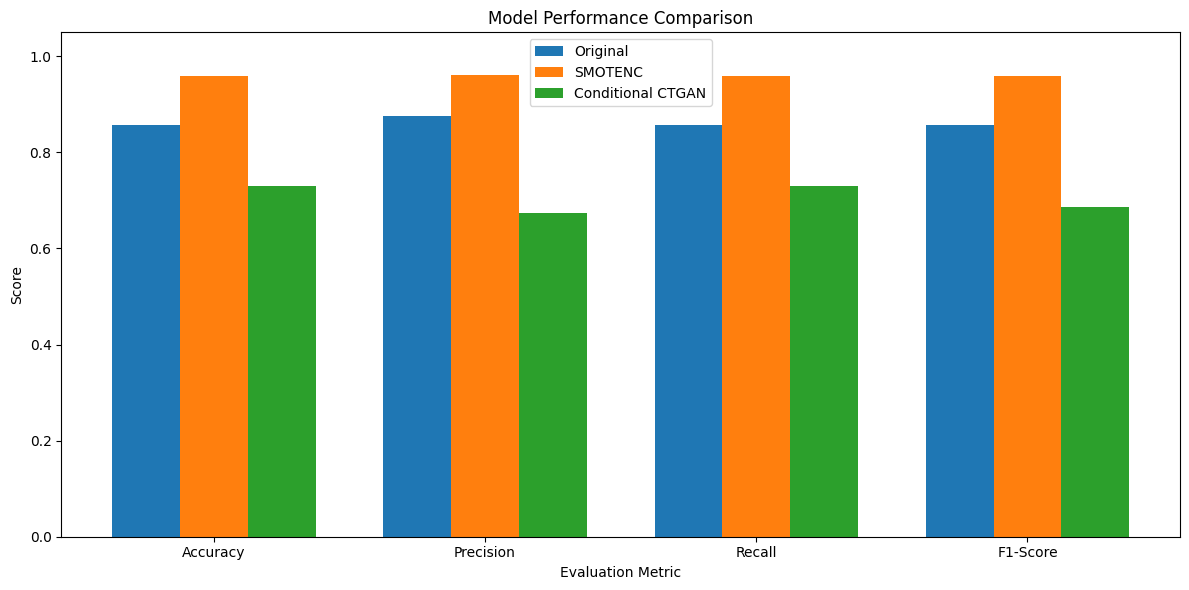

In [29]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

original_scores = [
    results_original['accuracy'],
    results_original['precision'],
    results_original['recall'],
    results_original['f1']
]

smotenc_scores = [
    results_smotenc['accuracy'],
    results_smotenc['precision'],
    results_smotenc['recall'],
    results_smotenc['f1']
]

ctgan_scores = [
    results_ctgan['accuracy'],
    results_ctgan['precision'],
    results_ctgan['recall'],
    results_ctgan['f1']
]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    [i - width for i in x],
    original_scores,
    width,
    label='Original'
)

plt.bar(
    x,
    smotenc_scores,
    width,
    label='SMOTENC'
)

plt.bar(
    [i + width for i in x],
    ctgan_scores,
    width,
    label='Conditional CTGAN'
)

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()

plt.savefig(
    'performance_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
from google.colab import files

files.download("performance_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>